K-Means Clustering digunakan untuk mengelompokkan data ke dalam beberapa klaster berdasarkan kesamaan karakteristik. Analisis ini menggunakan dataset **Mall Customers**, yang memuat berbagai informasi pelanggan. Sebagai langkah awal, proses klasterisasi akan difokuskan pada dua fitur utama, yaitu `Annual Income` dan `Spending Score`, untuk menyederhanakan pemahaman serta mempermudah visualisasi klaster. Pendekatan ini memungkinkan interpretasi hasil yang lebih intuitif sebelum melibatkan fitur lainnya.

In [3]:
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### Penjelasan:
Dataset `Mall_Customers.csv`,  isinya data 200 pelanggan: `CustomerID`, `Genre` (jenis kelamin), `Age`, `Annual Income (k$)` (pendapatan tahunan dalam ribuan dolar), dan `Spending Score (1-100)` (skor seberapa sering/besar mereka belanja). `.head()` dipakai buat ngintip 5 baris pertama, sekalian mastiin datanya kebaca bener.

In [4]:
# cek missing values
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

#### Penjelasan:
Ini memastikan tidak ada data yang kosong (NaN) di dataset ini. Hasilnya semua kolom nilainya 0, artinya datanya sudah bersih dan siap langsung dipakai, tanpa perlu proses handling missing value seperti di modul sebelumnya.

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### Penjelasan:
`.describe()` dipakai untuk melihat ringkasan statistik dari kolom-kolom numerik (`CustomerID`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`) sekaligus — mean, std, min, max, dan kuartilnya. Dari sini kelihatan misalnya umur pelanggan berkisar 18-70 tahun, dan pendapatan tahunan berkisar 15-137 (dalam ribuan dolar).

In [6]:
dataset = df.iloc[:,3:]
dataset.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


#### Penjelasan:
`df.iloc[:,3:]` mengambil semua kolom mulai dari index ke-3, yaitu `Annual Income (k$)` dan `Spending Score (1-100)` doang. Ini adalah dua fitur utama yang mau dipakai buat clustering tahap pertama, karena keduanya paling relevan buat ngelompokkin pelanggan berdasarkan "siapa yang boros dan siapa yang hemat".

In [7]:
x = df.iloc[:, 3]
y = df.iloc[:, 4]

#### Penjelasan:
Di sini `x` dan `y` dipisah masing-masing jadi satu Series: `x` = `Annual Income (k$)` (kolom index 3), `y` = `Spending Score (1-100)` (kolom index 4). Nanti kedua variabel ini dipakai buat plotting dan sebagai bahan clustering.

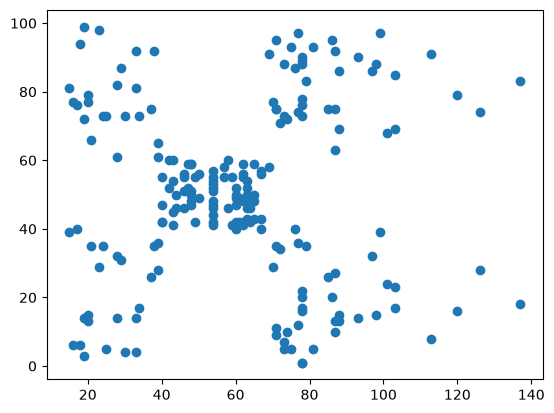

In [8]:
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.show()

#### Penjelasan:
Sebelum di-cluster, kita melihat dulu pola data secara visual. Dari scatter plot ini kelihatan ada beberapa "gumpalan" titik yang mengelompok di area tertentu misalnya ada gerombolan di income rendah dengan spending score tinggi, ada juga di income tinggi dengan spending score rendah, dan satu gerombolan besar di tengah. Pola seperti ini yang bikin data cocok untuk dikelompokkan pakai **K-Means Clustering**, karena matanya sendiri sudah bisa menangkap beberapa kelompok visual.

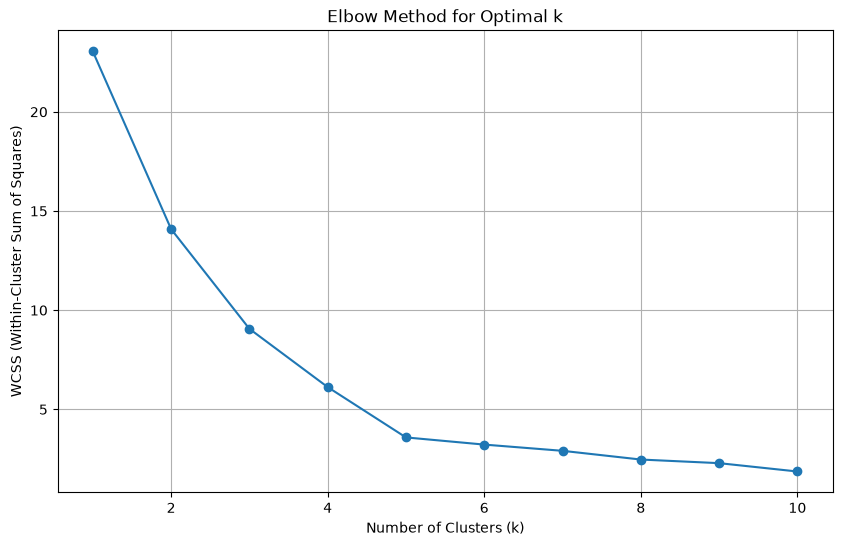

In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
# Scaling data dengan MinMaxScaler
scaler = MinMaxScaler()
# Mengambil kolom X (index 3) dan Y (index 4) dari DataFrame
X = pd.DataFrame({'Annual Income (k$)': x, 'Spending Score (1-100)': y})
X_scaled = scaler.fit_transform(X)
# Menentukan jumlah klaster optimal menggunakan Elbow Method
wcss = []
for i in range(1, 11): # Coba k dari 1 sampai 10
 kmeans = KMeans(n_clusters=i, random_state=42)
 kmeans.fit(X_scaled)
 wcss.append(kmeans.inertia_)
# Membuat plot Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

#### Penjelasan:
Ini bagian paling penting sebelum nge-cluster: nentuin **berapa jumlah klaster (k) yang paling optimal**. Caranya:
1. Data di-*scale* dulu pakai `MinMaxScaler()` — ini penting karena `Annual Income` (skalanya 15-137) dan `Spending Score` (skalanya 1-100) punya rentang nilai yang beda, kalau nggak di-scale, fitur dengan rentang lebih besar bisa "mendominasi" perhitungan jarak di K-Means.
2. **Elbow Method**: kita coba K-Means dengan `k` dari 1 sampai 10, dan untuk tiap `k` kita catat nilai `inertia_` (disimpan sebagai `wcss`, singkatan dari *Within-Cluster Sum of Squares* — total jarak kuadrat tiap titik ke pusat klasternya). Semakin banyak klaster, nilai WCSS pasti makin kecil (karena titik-titiknya makin deket sama centroid masing-masing), tapi penurunannya akan melambat di titik tertentu.
3. Titik di mana grafiknya mulai "menekuk" seperti siku (*elbow*) itu yang dianggap jumlah klaster paling optimal — nambah klaster setelah titik itu nggak banyak membantu lagi mengurangi WCSS, cuma nambah kompleksitas.

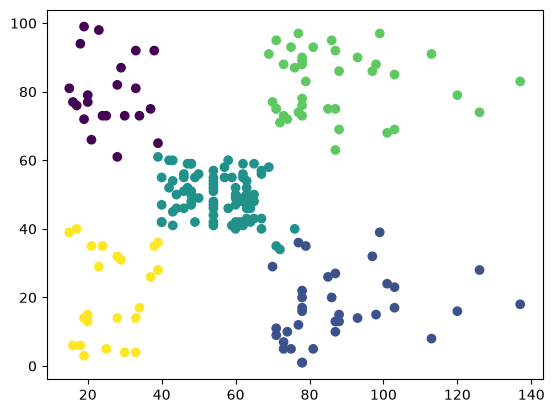

In [10]:
# dari elbow method, nilai k optimal untuk data ini adalah 5
kmeans = KMeans(n_clusters=5)
kmeans.fit(X)
# Plot hasil klaster
plt.scatter(x, y, c=kmeans.labels_)
plt.show()

#### Penjelasan:
Dari grafik Elbow sebelumnya, titik siku-nya kelihatan di sekitar `k=5`, jadi di sini kita latih K-Means dengan 5 klaster. `kmeans.labels_` berisi label klaster (0, 1, 2, 3, atau 4) untuk setiap pelanggan, yang dipakai buat mewarnai titik-titik di scatter plot.

Hasilnya kelihatan jelas 5 kelompok warna yang masing-masing mewakili karakteristik pelanggan berbeda, misalnya: income rendah-spending tinggi, income rendah-spending rendah, income tinggi-spending tinggi, income tinggi-spending rendah, dan kelompok "tengah" yang income dan spending-nya sedang-sedang saja. Ini jauh lebih rapi dibanding scatter plot awal yang semua titiknya masih satu warna.

Selanjutnya klasterisasi dilakukan dengan menggunakan tiga fitur utama, yaitu **Age**, **Annual Income**, dan **Spending Score**.

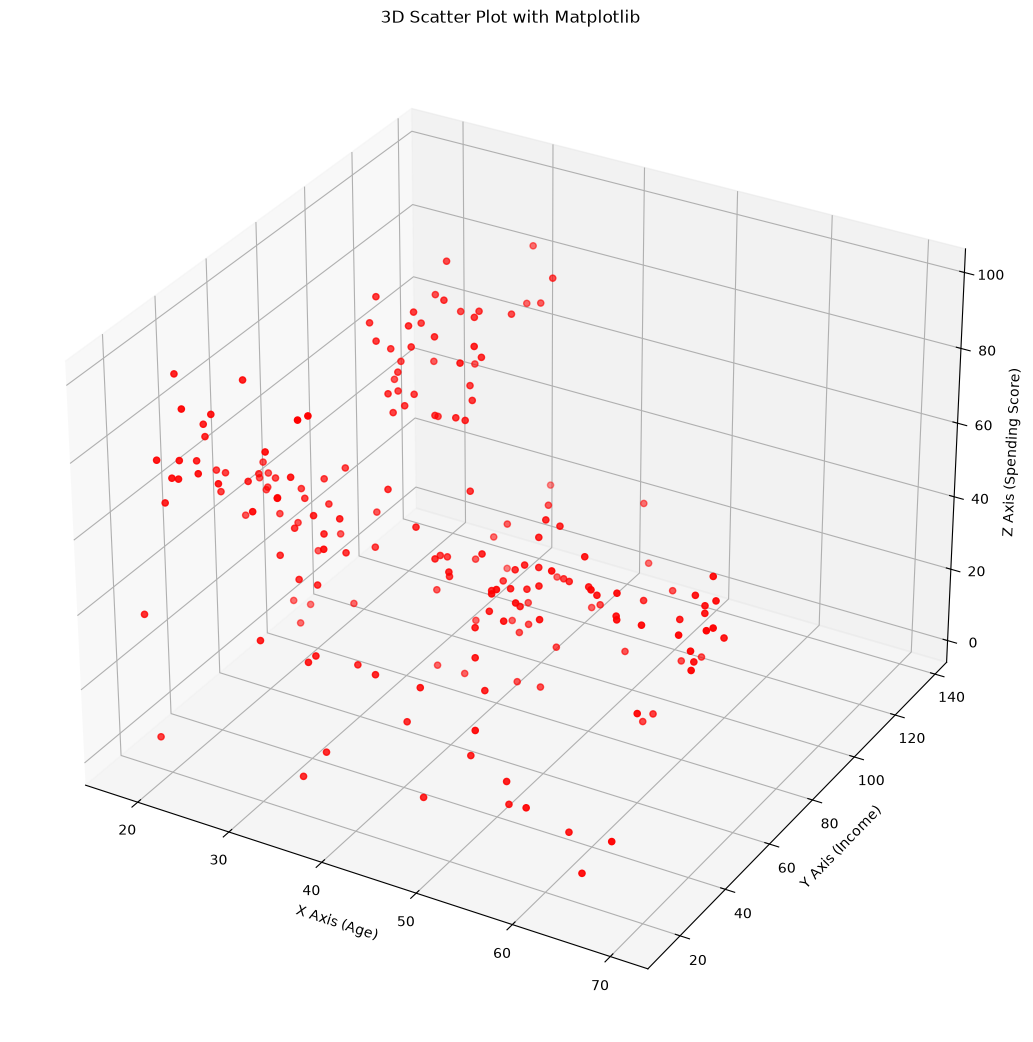

In [11]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
# Data Age, Annual Income, dan Spending Score
x = df.iloc[:, 2]
y = df.iloc[:, 3]
z = df.iloc[:, 4]
# Membuat plot 3D
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')
# Plot data
ax.scatter(x, y, z, c='red', marker='o')
# Label sumbu
ax.set_xlabel('X Axis (Age)')
ax.set_ylabel('Y Axis (Income)')
ax.set_zlabel('Z Axis (Spending Score)')
plt.title('3D Scatter Plot with Matplotlib')
plt.show()

#### Penjelasan:
Sekarang kita perluas analisisnya dengan menambahkan fitur `Age`, jadi totalnya ada 3 fitur: `Age` (sumbu X), `Annual Income` (sumbu Y), `Spending Score` (sumbu Z). Karena sekarang ada 3 dimensi, kita gambar pakai **3D scatter plot** supaya bisa melihat posisi tiap pelanggan di ruang 3 dimensi tersebut. Di tahap ini titik-titiknya masih diwarnai merah semua (belum di-cluster), cuma buat ngintip bentuk sebaran datanya dulu.

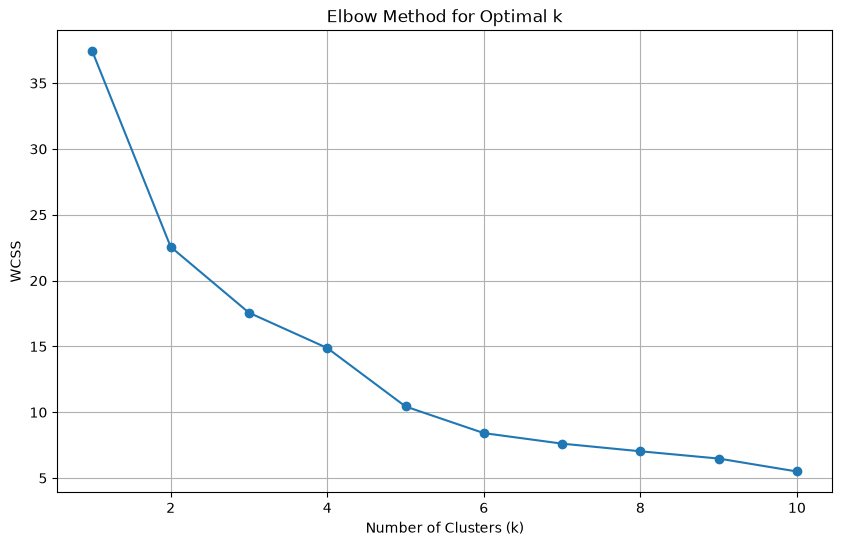

In [12]:
# Menggabungkan data X, Y, Z menjadi array untuk clustering
X = np.array(list(zip(x, y, z)))
# Scaling data dengan MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
# Menentukan jumlah klaster optimal dengan Elbow Method
wcss = []
for i in range(1, 11):
 kmeans = KMeans(n_clusters=i, random_state=42)
 kmeans.fit(X_scaled)
 wcss.append(kmeans.inertia_)
# Visualisasi Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

#### Penjelasan:
Sama seperti sebelumnya, tapi sekarang Elbow Method dihitung untuk **3 fitur sekaligus** (`Age`, `Annual Income`, `Spending Score`), bukan cuma 2. Ketiga fitur digabung jadi satu array pakai `np.array(list(zip(x, y, z)))`, lalu di-scale lagi pakai `MinMaxScaler()` dengan alasan yang sama seperti tadi (biar skalanya setara). Dari grafik Elbow yang baru ini, bentuk siku-nya sedikit berbeda dari yang pertama karena sekarang ada satu fitur tambahan (`Age`) yang ikut mempengaruhi pengelompokan.

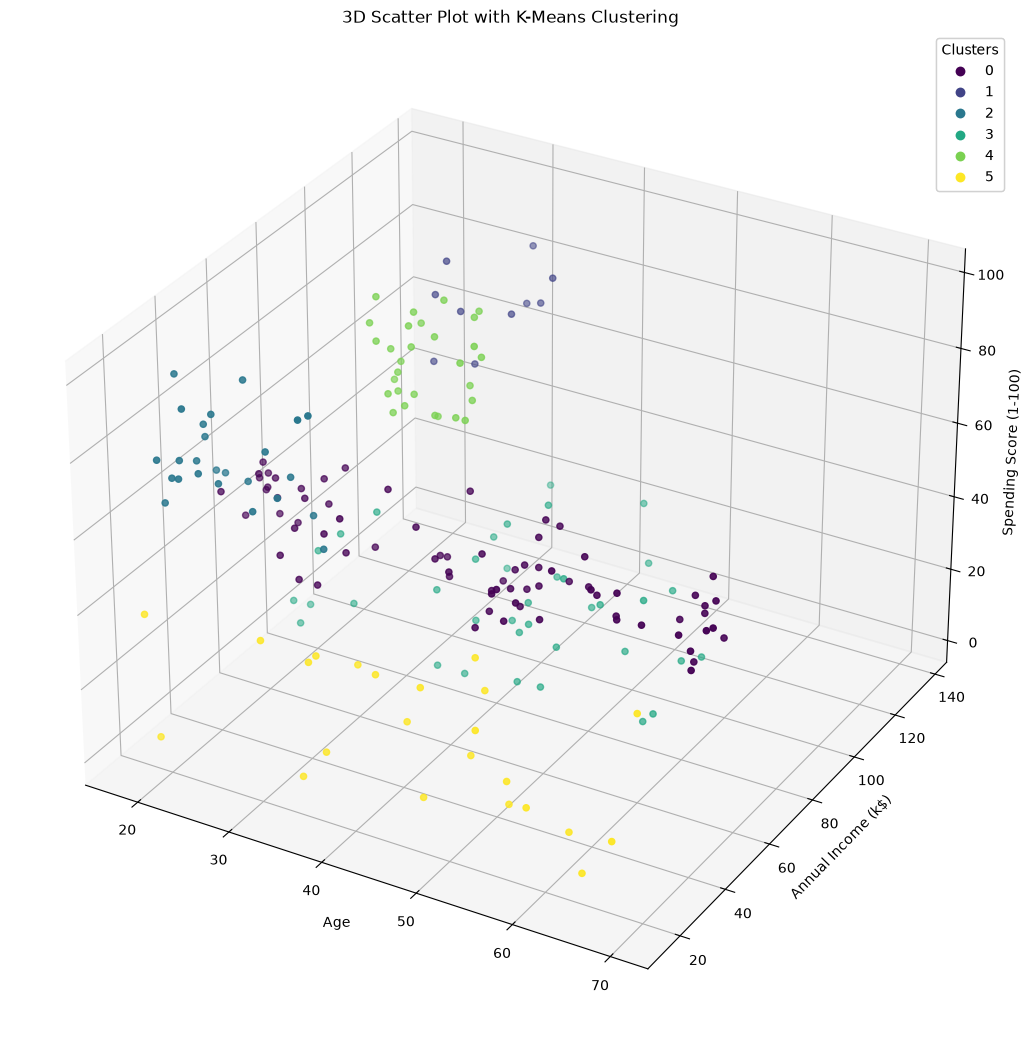

In [13]:
# Pilih k optimal setelah melihat Elbow
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X)
# Menambahkan hasil klaster ke DataFrame
df['Cluster'] = clusters
# Visualisasi 3D Hasil K-Means
# Plot data dengan warna berdasarkan klaster
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')
# Plot setiap titik dengan warna sesuai klaster
scatter = ax.scatter(x, y, z, c=clusters, cmap='viridis', marker='o')
# Label sumbu
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
# Menampilkan legenda klaster
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)
plt.title('3D Scatter Plot with K-Means Clustering')
plt.show()

#### Penjelasan:
Dari grafik Elbow di langkah sebelumnya, kali ini dipilih `k=6` sebagai jumlah klaster optimal untuk kombinasi 3 fitur ini. `kmeans.fit_predict(X)` langsung melatih model **dan** mengembalikan label klaster untuk tiap baris data sekaligus (gabungan dari `.fit()` + `.predict()`). Hasil klasternya juga disimpan ke kolom baru `df['Cluster']`, jadi tiap pelanggan di DataFrame asli sekarang punya label kelompoknya masing-masing.

Visualisasi 3D terakhir ini menunjukkan 6 kelompok pelanggan (warna 0-5) berdasarkan kombinasi `Age`, `Annual Income`, dan `Spending Score`. Dengan informasi ini, pihak mall bisa membuat strategi pemasaran yang lebih tepat sasaran untuk tiap kelompok — misalnya kelompok usia muda dengan spending score tinggi mungkin cocok ditargetkan promo fashion, sementara kelompok usia lebih tua dengan income tinggi tapi spending rendah mungkin perlu pendekatan promosi yang berbeda.